In [1]:
import matplotlib.pyplot as plt
import sys, os
import py21cmfast as p21c
from py21cmfast import plotting
import numpy as np
from scipy import interpolate, integrate
from astropy import cosmology, units, constants
from matplotlib import cm, colors, rc

/Users/adeliegorce/opt/anaconda3/envs/21cmfast/lib/python3.9/site-packages/py21cmfast/_cfg.py:57: UserWarning: Your configuration file is out of date. Updating...
  warnings.warn(
/Users/adeliegorce/opt/anaconda3/envs/21cmfast/lib/python3.9/site-packages/py21cmfast/_cfg.py:41: UserWarning: Your configuration file is out of date. Updating...
  warnings.warn("Your configuration file is out of date. Updating...")


In [2]:
print(f"21cmFAST version is {p21c.__version__}")

21cmFAST version is 3.3.1


In [5]:
from utils import *

In [6]:
rc('font',**{'family':'serif', 'serif':['times new roman'], 'size': 18})
rc('text', usetex=True)

In [7]:
%matplotlib inline

In [8]:
# Cosmology
cos = cosmology.Planck18
Yp = 0.2453 # primordial fraction of He
Xp = 1. - Yp # primordial fraction of H
mh = constants.m_n #kg, mass of H atom
rhoc = cos.critical_density0.si #kg m-3, critical density of the Universe
nh = Xp*cos.Ob0*rhoc/mh  # m-3, number density of H 
fH = 1. #ignore He reion at this point

In [9]:
# Constants
s_T = constants.sigma_T    # sigma_thomson in SI units [m^2]
c = constants.c   # speed of light in SI units [m.s-1]
Mpcm = (1.0 * units.Mpc).to(units.m)  # one Mpc in [m]
Mpckm = Mpcm / 1e3

In [10]:
zmin = 5.0
zmax = 15.0

N=200
L=200.

In [11]:
lc = p21c.run_lightcone(
    redshift = zmin,
    max_redshift = zmax,
    user_params = {"HII_DIM":N, "BOX_LEN": L,
                   "N_THREADS": 5,'USE_INTERPOLATION_TABLES':True},
    lightcone_quantities=("brightness_temp", 'density','xH_box', 'velocity'), # The quantities to form into a lc. By default, just the brightness temperature.
    global_quantities=("brightness_temp", 'density', 'xH_box', 'velocity'), # The quantities to save as globally-averaged redshift-dependent functions.These may be any of the quantities that can be used in ``lc_quantities``.The mean is taken over the full 3D cube at each redshift, rather than a 2Dslice.
    flag_options = {"USE_MASS_DEPENDENT_ZETA":True},
    random_seed=12345,
    direc= '_cache'
)

/Users/adeliegorce/opt/anaconda3/envs/21cmfast/lib/python3.9/site-packages/py21cmfast/_utils.py:400: UserWarning: The following parameters to FlagOptions are not supported: ['USE_VELS_AUX']
  warnings.warn(
/Users/adeliegorce/opt/anaconda3/envs/21cmfast/lib/python3.9/site-packages/py21cmfast/_utils.py:815: UserWarning: Trying to remove array that isn't yet created: hires_vx
  warnings.warn(f"Trying to remove array that isn't yet created: {k}")
/Users/adeliegorce/opt/anaconda3/envs/21cmfast/lib/python3.9/site-packages/py21cmfast/_utils.py:815: UserWarning: Trying to remove array that isn't yet created: hires_vy
  warnings.warn(f"Trying to remove array that isn't yet created: {k}")
/Users/adeliegorce/opt/anaconda3/envs/21cmfast/lib/python3.9/site-packages/py21cmfast/_utils.py:815: UserWarning: Trying to remove array that isn't yet created: hires_vz
  warnings.warn(f"Trying to remove array that isn't yet created: {k}")
/Users/adeliegorce/opt/anaconda3/envs/21cmfast/lib/python3.9/site-pack

(<Figure size 3812x550 with 2 Axes>,
 <AxesSubplot: xlabel='Redshift', ylabel='y-axis [Mpc]'>)

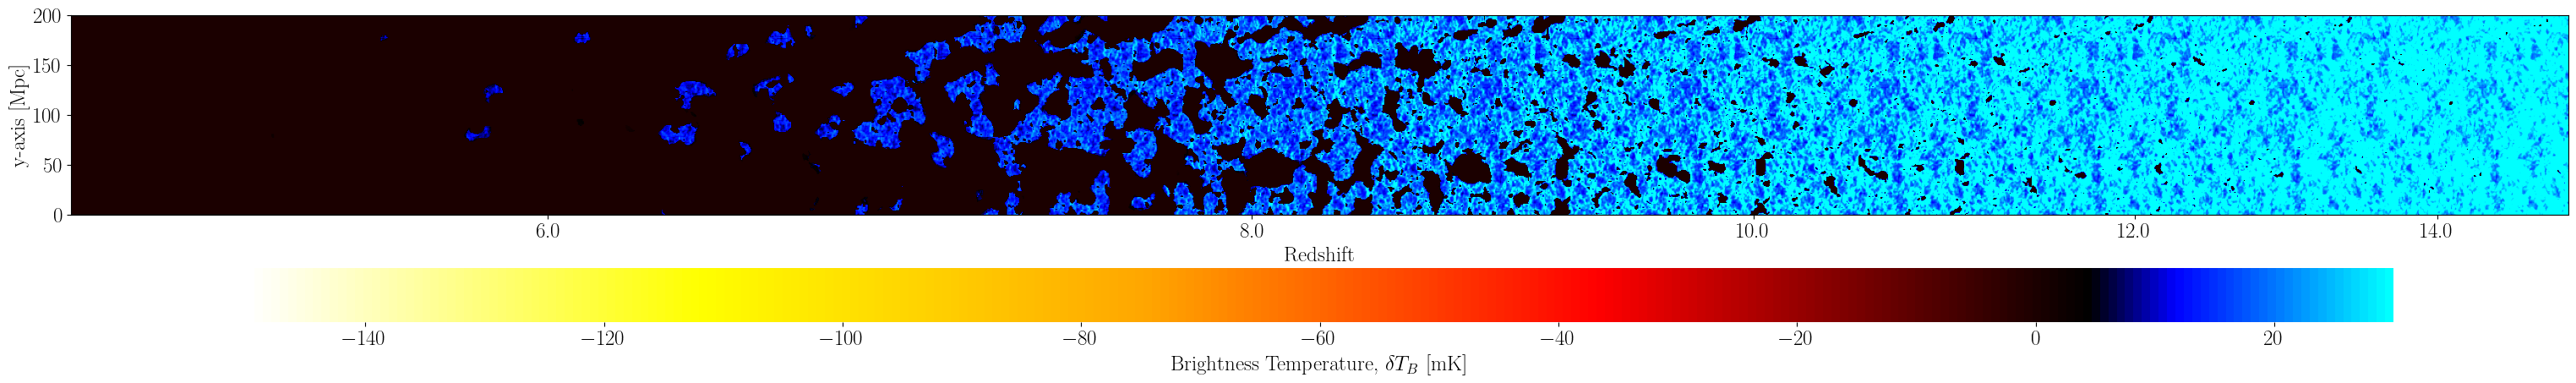

In [12]:
plotting.lightcone_sliceplot(lc)

\begin{equation}
\tau(z)=c\left\langle n_{\mathrm{H}}\right\rangle \sigma_{\mathrm{T}} \int_{z_\mathrm{recomb}}^z \frac{x_e\left(z^{\prime}\right)}{H\left(z^{\prime}\right)}\left(1+z^{\prime}\right)^2 \mathrm{~d} z^{\prime}
\end{equation}

In [13]:
# extract lc redshift nodes and corresponding redshifts
zz = np.array(lc.lightcone_redshifts)[::-1]
lc_dists = np.array(lc.lightcone_distances)[::-1]
n_lc = len(zz)

In [14]:
dtau_lc = c * s_T * nh * (1. - lc.xH_box[..., ::-1]) * (1. + lc.density[..., ::-1]) / cos.H(zz).si[None, None, :] \
            * (1 + zz[None, None, :])**2 * fH
tau_lc = -integrate.cumulative_trapezoid(dtau_lc, zz, initial=0)

In [15]:
z_nodes = np.array(lc.node_redshifts)
glob_density = np.array(lc.global_density)
glob_xHII = np.array(1. - lc.global_xH)
glob_fH = np.ones(z_nodes.shape) * fH #first helium reionisation
integ_tau = c * s_T * nh * glob_xHII * glob_fH / cos.H(z_nodes).si * (1+z_nodes)**2
tau_global = -integrate.cumtrapz(integ_tau, z_nodes, initial=0)

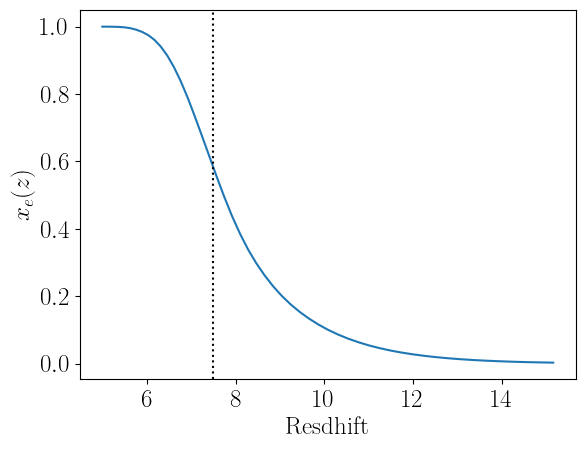

In [100]:
# plt.plot(z_nodes, -integrate.cumulative_trapezoid(glob_xHII, z_nodes, initial=0))
plt.plot(z_nodes, glob_xHII)
plt.xlabel('Resdhift')
plt.ylabel(r'$x_e(z)$')
plt.axvline(7.5, color='k', ls=':')

Text(0, 0.5, 'Optical depth')

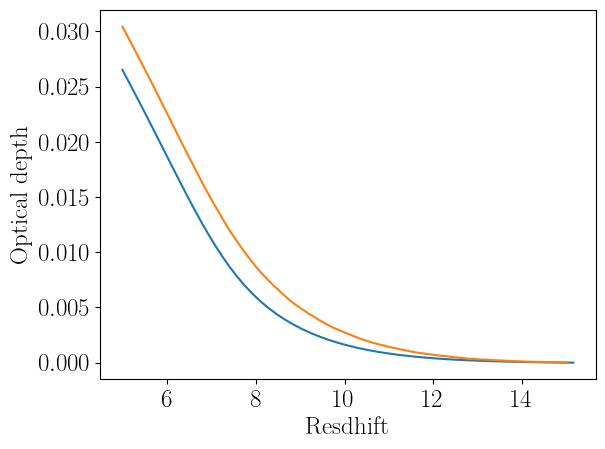

In [17]:
# plt.plot(z_nodes, -integrate.cumulative_trapezoid(glob_xHII, z_nodes, initial=0))
plt.plot(z_nodes, tau_global)
plt.plot(zz, np.mean(tau_lc, axis=(0,1)))
plt.xlabel('Resdhift')
plt.ylabel('Optical depth')

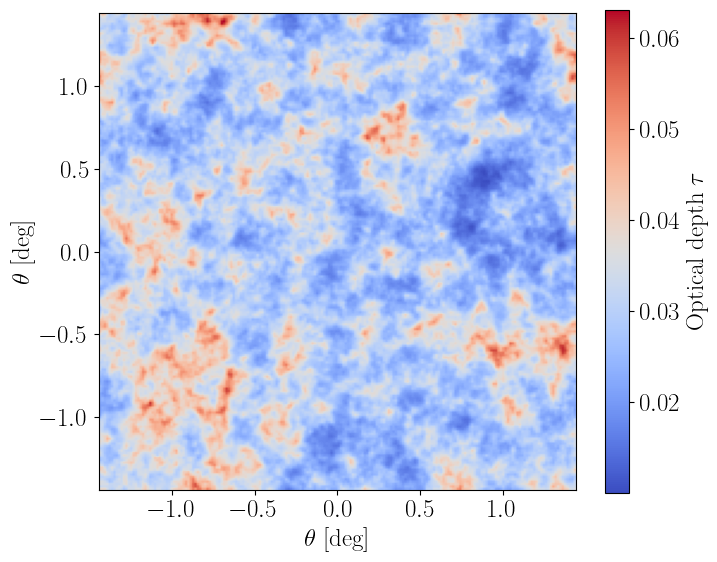

In [18]:
ii = -1
theta = 2.*np.arctan(L*units.Mpc/2./cos.comoving_distance(zz[ii])).to(units.degree).value

fig, ax = plt.subplots(1, 1, figsize=(7.5, 6))
im = ax.imshow(tau_lc[..., -1], cmap='coolwarm',
             origin='lower',
             extent=(-theta, theta, -theta, theta))
plt.colorbar(im, label=r'Optical depth $\tau$')
# ax.set_xlabel(r'$x$ [Mpc]')
ax.set_xlabel(r'$\theta$ [deg]')
# ax.set_ylabel(r'$y$ [Mpc]')
ax.set_ylabel(r'$\theta$ [deg]')
# ax.set_title(rf'$z={zz[ii]:.2f}$')
# print(tau_array.mean())
fig.tight_layout()

# fig.savefig(f'tau_map_z{zz[ii]:.1f}.png', dpi=220)
# fig.savefig(f'tau_map.pdf', dpi=220)


### kSZ

In [83]:
PARALLEL_APPROX = False
rotation = True

In [84]:
T_cmb = 2.7255
T_CMB_uK=T_cmb*1e6  

In [85]:
velocity = np.array(lc.velocity) #velocities along the line of sight (z direction), in cMpc/s when extracted from code
velocity = velocity*Mpcm.value #m/s
ion = (1-np.array(lc.xH_box))
deltab = np.array(lc.density)
dR = (L/N*units.Mpc).to(units.m)

In [95]:
tx, ty = 23, 97
Tcmb_3d= nh*s_T*dR*(1.0+deltab)*ion*velocity #this is used for tcmb contribution #unit 1
dtau_3d= nh*s_T*dR*(1.0+deltab)*ion  #this is used for tau_e contribution # unit 1

tau_array, Tcmb = np.zeros((N,N)), np.zeros((N,N))
for i in np.arange(0,n_lc):
    currZ = zz[i]
    inc = lc_dists[i] / lc_dists[0]  #increment for ray tracing

    dtau_3d_new=dtau_3d[:,:,i]*(1+currZ)**2 #tcmb and tau_e contribution with appropriate redshift dependecies
    Tcmb_3d_new=(1+currZ)*Tcmb_3d[:,:,i]

    if (PARALLEL_APPROX):
        new_dtau=np.copy(dtau_3d_new)
        new_tcmb=np.copy(Tcmb_3d_new)
    else:  ## in ray tracing, matrices have to be adjusted
        a=np.round(np.arange(-N/2,N/2)*inc + N*3/2)
        new_dtau=np.take(dtau_3d_new,a.astype(int),axis=0,mode='wrap')
        new_dtau=np.take(dtau_3d_new,a.astype(int), axis=1,mode='wrap')
        new_tcmb=np.take(Tcmb_3d_new,a.astype(int),axis=0,mode='wrap')
        new_tcmb=np.take(Tcmb_3d_new,a.astype(int), axis=1,mode='wrap')
    
    if rotation:
        if (i%100==0):
            tx, ty = np.random.randint(N), np.random.randint(N) 
        new_dtau=np.roll(new_dtau, (-tx,-ty), (0,1)) #shifting of tcmb so there is no object repetition
        new_tcmb=np.roll(new_tcmb, (-tx,-ty), (0,1)) #shifting of tcmb so there is no object repetition
                
    tau_array+=new_dtau  #tau_e updating
    Tcmb+=new_tcmb*np.exp(-tau_array) # tcmb contribution addition
    # print(inc,a[-1],currZ,np.mean(dtau_3d_new),np.mean(Tcmb_3d_new),np.mean(new_tcmb),np.mean(new_dtau))
# print(mean_taue_curr_z,np.mean(Tcmb))
Tcmb -= np.mean(Tcmb)
Tcmb /= constants.c.value

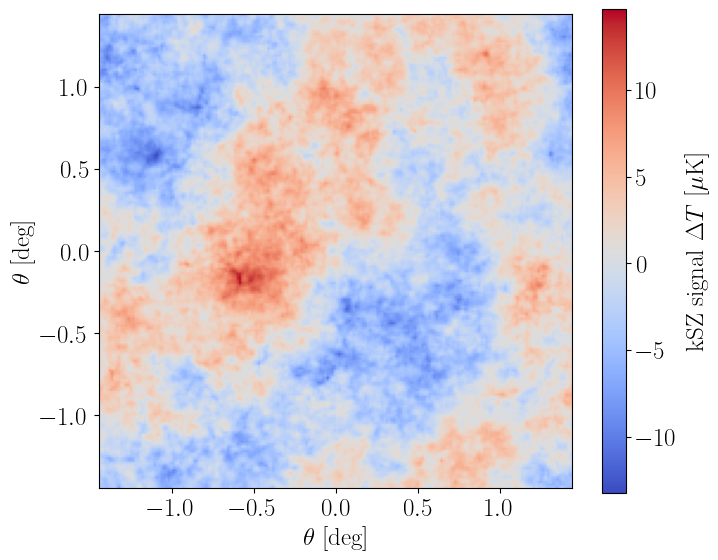

In [96]:
fig, ax = plt.subplots(1, 1, figsize=(7.5, 6))
im = ax.imshow(Tcmb*T_CMB_uK, cmap='coolwarm',
             origin='lower',
             extent=(-theta, theta, -theta, theta))
plt.colorbar(im, label=r'kSZ signal $\Delta T$ [$\mu$K]')
ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\theta$ [deg]')
fig.tight_layout()

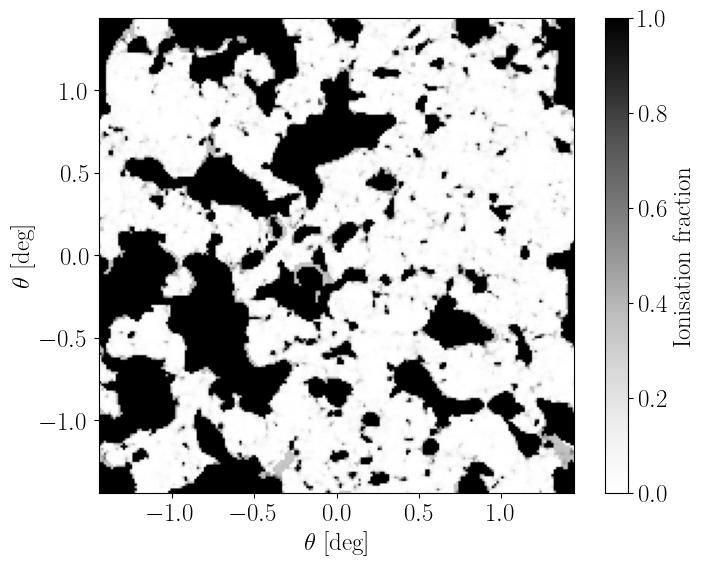

In [97]:
ii = np.argmin(np.abs(zz-8.4))
props = dict(boxstyle="round", facecolor="white", alpha=0.9)

fig, ax = plt.subplots(1, 1, figsize=(7.5, 6))
im = ax.imshow((1. - lc.xH_box[..., ::-1])[..., ii], cmap='Greys',
             origin='lower',
             extent=(-theta, theta, -theta, theta))
plt.colorbar(im, label=r'Ionisation fraction')
# ax.set_xlabel(r'$x$ [Mpc]')
ax.set_xlabel(r'$\theta$ [deg]')
# ax.set_ylabel(r'$y$ [Mpc]')
ax.set_ylabel(r'$\theta$ [deg]')
# ax.text(0.9, 0.9, rf'$z={zz[ii]:.2f}$', transform=ax.transAxes, fontsize=20, bbox=props)
fig.tight_layout()
# fig.savefig(f'xion_map_z{zz[ii]:.1f}.pdf', dpi=220)

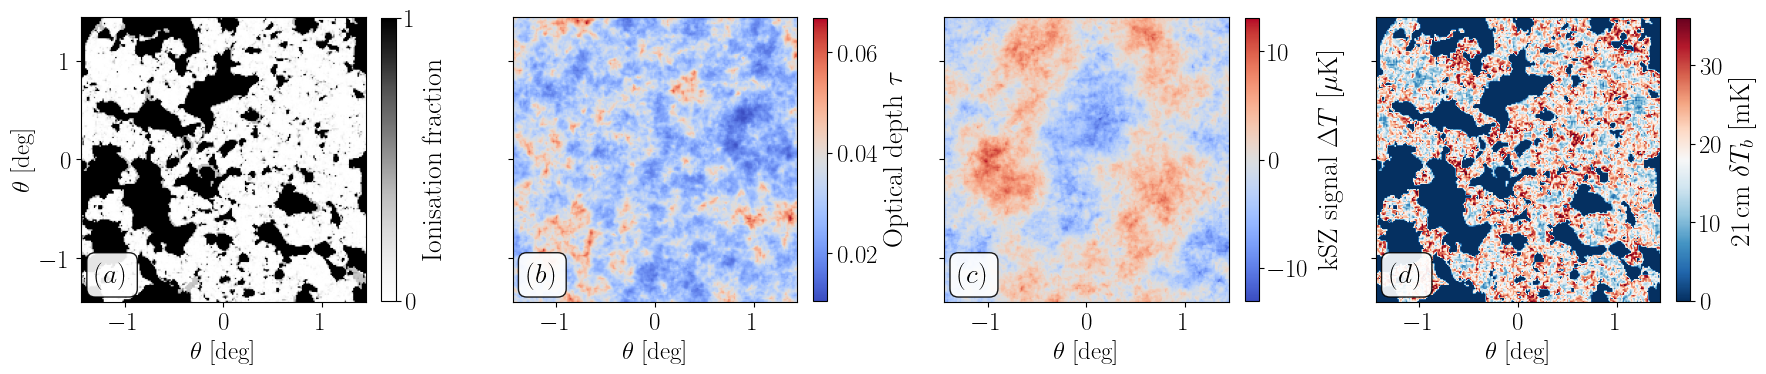

In [26]:
ii = np.argmin(np.abs(zz-8.4))
props = dict(boxstyle="round", facecolor="white", alpha=0.9)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

# ion map
im = axes[0].imshow((1. - lc.xH_box[..., ::-1])[..., ii], cmap='Greys',
             origin='lower',
             extent=(-theta, theta, -theta, theta))
cbar0 = plt.colorbar(im, ax=axes[0], ticks=[0,1], fraction=0.045)
cbar0.set_label(r'Ionisation fraction', fontsize=20)
axes[0].set_xlabel(r'$\theta$ [deg]')
axes[0].set_ylabel(r'$\theta$ [deg]')

# optical depth
im = axes[1].imshow(tau_lc[..., -1], cmap='coolwarm',
             origin='lower',
             extent=(-theta, theta, -theta, theta))
cbar = plt.colorbar(im, ax=axes[1], fraction=0.045)
cbar.set_label(r'Optical depth $\tau$', fontsize=20)
axes[1].set_xlabel(r'$\theta$ [deg]')

# ksz
im = axes[2].imshow(Tcmb*T_CMB_uK, cmap='coolwarm',
             origin='lower',
             extent=(-theta, theta, -theta, theta))
cbar2 = plt.colorbar(im, ax=axes[2], fraction=0.045)
cbar2.set_label(r'kSZ signal $\Delta T$ [$\mu$K]', fontsize=20)
axes[2].set_xlabel(r'$\theta$ [deg]')

# 21cm map
im = axes[3].imshow((lc.brightness_temp[..., ::-1])[..., ii], cmap='RdBu_r',
             origin='lower',
             extent=(-theta, theta, -theta, theta))
cbar3 = plt.colorbar(im, ax=axes[3], fraction=0.045)
cbar3.set_label(r'21\,cm $\delta T_b$ [mK]', fontsize=20)
axes[3].set_xlabel(r'$\theta$ [deg]')



for i, (letter, title) in enumerate(zip(['a', 'b', 'c', 'd'],
                                        ['Electron power spectrum', 'Optical depth', 'kSZ signal', '21\,cm signal'])):
    axes[i].text(0.05, 0.07, rf'$({letter})$', transform=axes[i].transAxes, fontsize=20, bbox=props)

fig.tight_layout()
# fig.savefig(f'xion_map_z{zz[ii]:.1f}.pdf', dpi=220)
fig.savefig('model2observables_maps.pdf', dpi=220)

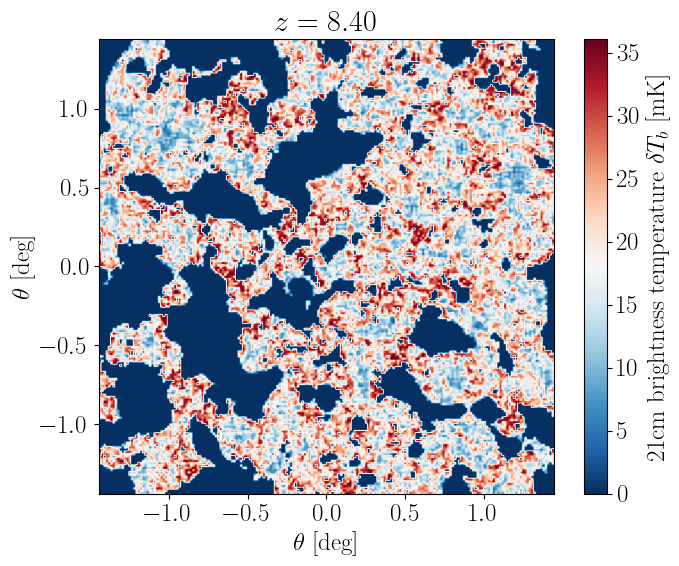

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(7.5, 6))
im = ax.imshow((lc.brightness_temp[..., ::-1])[..., ii], cmap='RdBu_r',
             origin='lower',
             extent=(-theta, theta, -theta, theta))
plt.colorbar(im, label=r'21cm brightness temperature $\delta T_b$ [mK]')
# ax.set_xlabel(r'$x$ [Mpc]')
ax.set_xlabel(r'$\theta$ [deg]')
# ax.set_ylabel(r'$y$ [Mpc]')
ax.set_ylabel(r'$\theta$ [deg]')
ax.set_title(rf'$z={zz[ii]:.2f}$')
fig.tight_layout()
fig.savefig(f'dTb_map_z{zz[ii]:.1f}.png', dpi=220)

In [ ]:
ii = 100
fig, ax = plt.subplots(1, 1, figsize=(7.5, 6))
im = ax.imshow((1. - lc.xH_box[..., ::-1])[..., ii], cmap='Greys',
             origin='lower',
             extent=(-theta, theta, -theta, theta))
plt.colorbar(im, label=r'Ionisation fraction')
# ax.set_xlabel(r'$x$ [Mpc]')
ax.set_xlabel(r'$\theta$ [deg]')
# ax.set_ylabel(r'$y$ [Mpc]')
ax.set_ylabel(r'$\theta$ [deg]')
ax.set_title(rf'$z={zz[ii]:.2f}$')
print(tau_array.mean())
fig.tight_layout()
# fig.savefig(f'xion_map_z{zz[ii]:.1f}.png', dpi=220)

In [36]:
kSZ_map = Tcmb*T_CMB_uK  # uK
tau_map = tau_lc[..., -1]  # unit 1

z21 = 8.4
ii = np.argmin(np.abs(zz-z21))
dTb_map = (lc.brightness_temp[..., ::-1])[..., ii] * 1000. # uK

fov = (theta*units.deg).to(units.rad).value

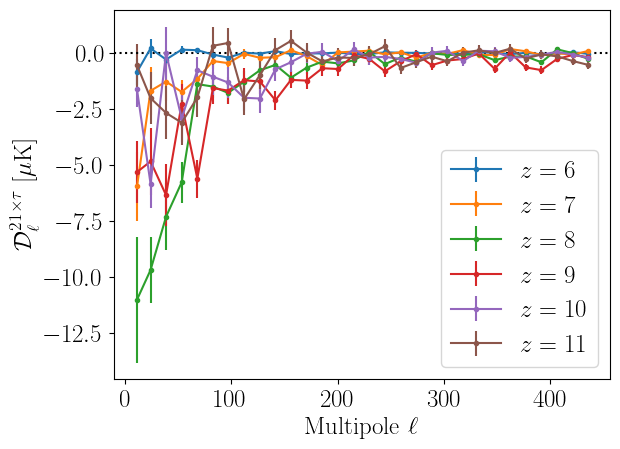

In [43]:
fig, ax = plt.subplots()
for z21 in np.arange(6, 12):
        ii = np.argmin(np.abs(zz-z21))
        dTb_map_temp = (lc.brightness_temp[..., ::-1])[..., ii] * 1000. # uK
        l, cl_tau_21, el_tau_21 = compute_cross_angular_spectrum(tau_map, dTb_map_temp, theta, nbins=30)
        m = cl_tau_21 != 0.
        ax.errorbar(
                l[m], l[m] * (l[m]+1.) * cl_tau_21[m] / 2. / np.pi,
                yerr=l[m] * (l[m]+1.) * el_tau_21[m] / 2./np.pi,
                marker='.', label=rf'$z={z21}$')
# ax.set_ylim(1e-3, 1e6)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}^{21\times \tau}_\ell$ [$\mu$K]')
plt.axhline(0, color='k', ls=':')
plt.legend()

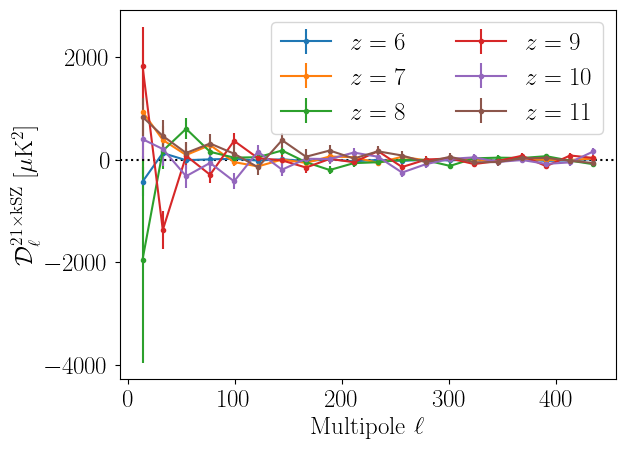

In [56]:
fig, ax = plt.subplots()
for z21 in np.arange(6, 12, 1):
        ii = np.argmin(np.abs(zz-z21))
        dTb_map_temp = (lc.brightness_temp[..., ::-1])[..., ii] * 1000. # uK
        l, cl_ksz_21, el_ksz_21 = compute_cross_angular_spectrum(kSZ_map, dTb_map_temp, theta, nbins=20)
        m = cl_ksz_21 != 0.
        ax.errorbar(
                l[m], l[m] * (l[m]+1.) * cl_ksz_21[m] / 2. / np.pi,
                yerr=l[m] * (l[m]+1.) * el_ksz_21[m] / 2./np.pi,
                marker='.', label=rf'$z={z21}$')
# ax.set_ylim(1e-3, 1e6)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}^{21\times \mathrm{kSZ}}_\ell$ [$\mu$K$^2$]')
plt.axhline(0, color='k', ls=':')
plt.legend(ncols=2)
# plt.ylim(-100, 100)
# plt.yscale('symlog', linthresh=1.)